Starting PPO training for 3000 episodes...


100%|██████████| 3000/3000 [18:30<00:00,  2.70it/s]


Training completed!


C:\Users\iamro\AppData\Local\Temp\ipykernel_16356\1587572283.py:732: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  plt.tight_layout()


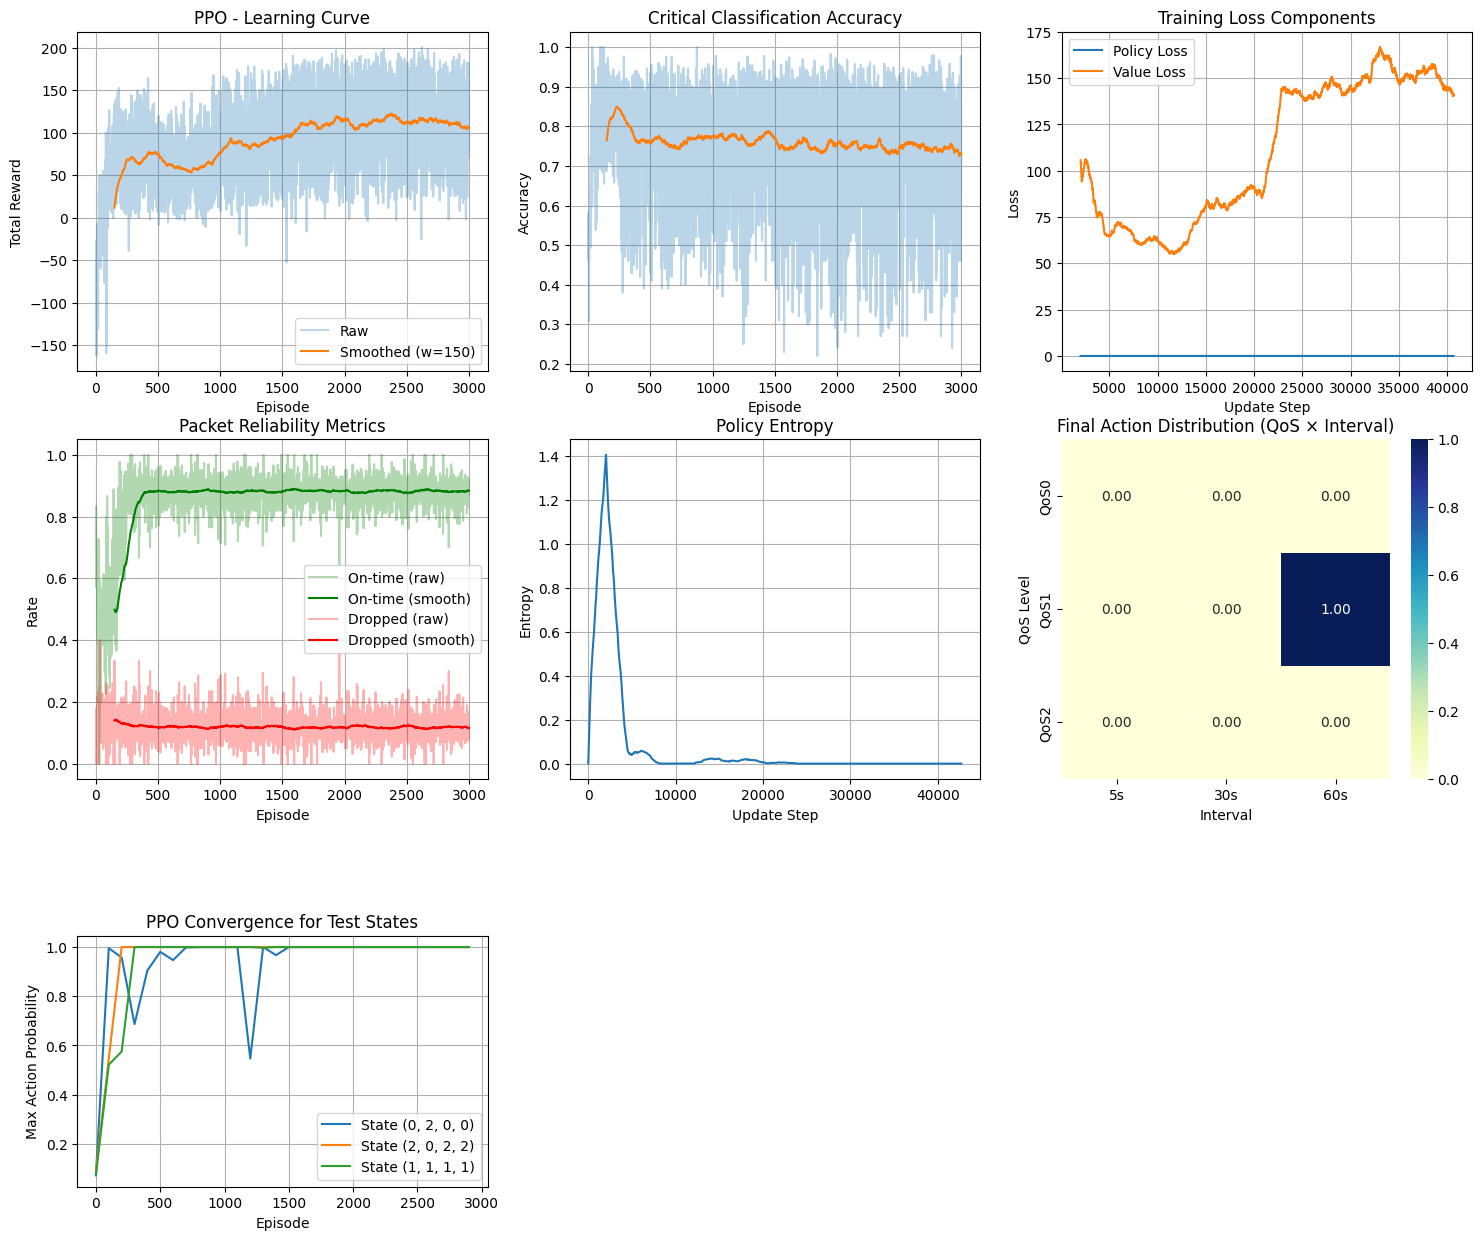


PPO Policy Analysis with Expected Ideal Actions:

State (Δ0, B=2, L=0, D=0):
  Best action: QoS=1, Interval=60s, Critical=1
  Ideal QoS: 0, Ideal Interval: 5s
  Critical match: ✗
  Top 1: QoS=1✗, τ=60s✗, c=1 (P=1.000)
  Top 2: QoS=0✓, τ=60s✗, c=0 (P=0.000)
  Top 3: QoS=1✗, τ=30s✗, c=0 (P=0.000)

State (Δ2, B=0, L=2, D=2):
  Best action: QoS=1, Interval=60s, Critical=1
  Ideal QoS: 2, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=1✗, τ=60s✗, c=1 (P=1.000)
  Top 2: QoS=0✗, τ=60s✗, c=0 (P=0.000)
  Top 3: QoS=1✗, τ=30s✗, c=0 (P=0.000)

State (Δ1, B=1, L=1, D=1):
  Best action: QoS=1, Interval=60s, Critical=1
  Ideal QoS: 1, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=1✓, τ=60s✗, c=1 (P=1.000)
  Top 2: QoS=0✗, τ=60s✗, c=0 (P=0.000)
  Top 3: QoS=1✓, τ=30s✗, c=0 (P=0.000)

=== Final Metrics ===
Metric                    |      Value
--------------------------------------
Average Reward            |     104.83
Accuracy                  |     71.88%
Avg KL Divergence         |   

In [ ]:
# PPO implementation (base)
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque, namedtuple, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.distributions import Categorical


class RealisticEnvSimulator:
    def __init__(self):
        self.battery = 1.0
        self.window_size = 20
        self.delay_window = []
        self.loss_window = []
        self.delta_ema = None
        self.delta_alpha = 0.1
        self.delta_std = 1.0

    def update_ema(self, x):
        if self.delta_ema is None:
            self.delta_ema = x
        else:
            self.delta_ema = self.delta_alpha * x + \
                (1 - self.delta_alpha) * self.delta_ema
        return self.delta_ema

    def compute_delta(self, x):
        ema = self.update_ema(x)
        delta = abs(x - ema) / (self.delta_std + 1e-8)
        return delta

    def compute_loss_rate(self):
        if len(self.loss_window) < self.window_size:
            return 0.0
        return 1.0 - np.mean(self.loss_window[-self.window_size:])

    def compute_avg_delay(self):
        if len(self.delay_window) == 0:
            return 0
        return np.mean(self.delay_window[-self.window_size:])

    def discretize_state(self, delta, battery, loss, delay):
              
        if delta < 1:
            delta_lvl = 0  
        elif delta < 3:
            delta_lvl = 1  
        else:
            delta_lvl = 2           
        
        if battery < 0.3:
            battery_lvl = 0   
        elif battery < 0.7:
            battery_lvl = 1  
        else:
            battery_lvl = 2             

      
        if loss < 0.1:
            loss_lvl = 0    
        elif loss < 0.3:
            loss_lvl = 1  
        else:
            loss_lvl = 2             

        
        if delay < 100:
            delay_lvl = 0    
        elif delay < 500:
            delay_lvl = 1  
        else:
            delay_lvl = 2            

        return delta_lvl, battery_lvl, loss_lvl, delay_lvl

    def simulate_environment(self, state, action):
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state
        qos, interval, critical = action

       
        sensor_value = np.random.uniform(10, 30) 
        delta = self.compute_delta(sensor_value)

    
        qos_energy = 0.05 * qos
        interval_energy = 2.0 / interval
        energy_cost = qos_energy + interval_energy
        self.battery = max(0.0, self.battery - energy_cost * 0.05)

        
        base_delay = np.random.normal(100 + 50 * (2 - qos), 20)
        delay = np.clip(base_delay + 1000 / interval, 0, 800)
        self.delay_window.append(delay)

        
        loss_chance = 0.1 * (2 - qos) + 0.01 * delay / \
            100 
        is_delivered = np.random.rand() > loss_chance
        self.loss_window.append(int(is_delivered))

        
        packet_status = 'dropped'
        if is_delivered:
            packet_status = 'on_time' if delay < 300 else 'late'
        latency = delay if is_delivered else 1000

       
        next_delta_lvl = 0 if delta < 1 else (1 if delta < 3 else 2)
        next_battery_lvl = 0 if self.battery < 0.3 else (
            1 if self.battery < 0.7 else 2)
        loss_rate = self.compute_loss_rate()
        next_loss_lvl = 0 if loss_rate < 0.1 else (1 if loss_rate < 0.3 else 2)
        avg_delay = self.compute_avg_delay()
        next_delay_lvl = 0 if avg_delay < 100 else (
            1 if avg_delay < 500 else 2)

        new_state = (next_delta_lvl, next_battery_lvl,
                     next_loss_lvl, next_delay_lvl)

      
        total_risk = delta_lvl + (2 - battery_lvl) + loss_lvl + delay_lvl + qos
        normalized_risk = total_risk / 5
        true_crit = 1 if normalized_risk >= 1 else 0

        return new_state, packet_status, true_crit, energy_cost, latency



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Transition = namedtuple('Transition',
                        ('state', 'action', 'reward', 'next_state', 'done', 'log_prob', 'value'))


class PPOBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
        self.states = []
        self.actions = []
        self.rewards = []
        self.next_states = []
        self.dones = []
        self.log_probs = []
        self.values = []
        self.advantages = []
        self.returns = []

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def clear_episode_data(self):
        self.states = []
        self.actions = []
        self.rewards = []
        self.next_states = []
        self.dones = []
        self.log_probs = []
        self.values = []

    def store_episode_data(self, state, action, reward, next_state, done, log_prob, value):
        self.states.append(torch.tensor(state, dtype=torch.float32))
        self.actions.append(action)
        self.rewards.append(reward)
        self.next_states.append(next_state)
        self.dones.append(done)
        self.log_probs.append(log_prob)
        self.values.append(value)

    def compute_advantages(self, gamma=0.99, gae_lambda=0.95):
       
        rewards = np.array(self.rewards)
        values = np.array(self.values)
        dones = np.array(self.dones)

        
        advantages = np.zeros_like(rewards)
        last_advantage = 0
        last_value = values[-1]

        for t in reversed(range(len(rewards))):
            if t + 1 < len(rewards):
                delta = rewards[t] + gamma * \
                    values[t+1] * (1 - dones[t]) - values[t]
            else:
                delta = rewards[t] + gamma * \
                    last_value * (1 - dones[t]) - values[t]
            advantages[t] = delta + gamma * \
                gae_lambda * (1 - dones[t]) * last_advantage
            last_advantage = advantages[t]

   
        self.returns = advantages + values

       
        self.advantages = (advantages - advantages.mean()) / \
            (advantages.std() + 1e-8)

      
        self.states = torch.FloatTensor(np.array(self.states)).to(device)
        self.actions = torch.LongTensor(np.array(self.actions)).to(device)
        self.log_probs = torch.FloatTensor(np.array(self.log_probs)).to(device)
        self.returns = torch.FloatTensor(self.returns).to(device)
        self.advantages = torch.FloatTensor(self.advantages).to(device)

        return len(self.states)


class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ActorCritic, self).__init__()

      
        self.shared_layers = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU()
        )

     
        self.actor = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

      
        self.critic = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        shared_features = self.shared_layers(x)
        action_probs = torch.softmax(self.actor(shared_features), dim=-1)
        state_values = self.critic(shared_features)
        return action_probs, state_values


class PPOAgent:
    def __init__(self):
        self.env = RealisticEnvSimulator()

      
        self.qos_levels = [0, 1, 2]
        self.intervals = [5, 30, 60]  
        self.critical_flags = [0, 1]
        self.state_action_visits = defaultdict(int)
        self.state_visits = defaultdict(int)
     
        self.state_dims = [3, 3, 3, 3]
        self.state_dim = len(self.state_dims)
        self.action_dims = [3, 3, 2]  
        self.num_actions = np.prod(self.action_dims)

       
        self.gamma = 0.99
        self.gae_lambda = 0.95
        self.clip_param = 0.10
        self.ppo_epochs = 6
        self.num_minibatches = 2
        self.lr = 1e-3
        self.entropy_coef = 0.005
        self.value_loss_coef = 0.4
        self.max_grad_norm = 0.8

  
        self.policy = ActorCritic(self.state_dim, self.num_actions).to(device)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=self.lr)

     
        self.buffer = PPOBuffer(50000)

       
        self.reward_weights = {
            'timeliness': 1.5,
            'criticality': 2.0,
            'qos_match': 2.0,
            'interval_match': 2.0,
            'tau_cost': 1.0,
            'qos_cost': 1.0,
            'kappa': 2.0,
            'latency_penalty': 0.5
        }

        
        self.metrics = {
            'episode_rewards': [],
            'classification_accuracy': [],
            'energy_consumption': [],
            'on_time_rate': [],
            'drop_rate': [],
            'avg_latency': [],
            'action_distribution': defaultdict(list),
            'convergence_data': [],
            'loss_values': [],
            'qos_distribution': [],
            'value_loss': [],
            'policy_loss': [],
            'entropy': [],
            'kl_divergence': [],  
            'clip_fraction': []
        }

    def action_to_index(self, qos, interval, critical):
        interval_idx = self.intervals.index(interval)
        return qos * 6 + interval_idx * 2 + critical

    def state_to_index(self, delta_lvl, battery_lvl, loss_lvl, delay_lvl):
        return (delta_lvl * 27 + battery_lvl * 9 + loss_lvl * 3 + delay_lvl)
    def index_to_action(self, action_idx):
        qos = action_idx // 6
        remainder = action_idx % 6
        interval_idx = remainder // 2
        critical = remainder % 2
        return qos, self.intervals[interval_idx], critical

    def _get_ideal_qos(self, state):
        
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state

        
        if loss_lvl >= 2 or delay_lvl >= 2 or delta_lvl >= 2:
            return 2
        elif (loss_lvl >= 1 or delay_lvl >= 1) and battery_lvl >= 1:
            return 1
        else:
            return 0

    def _get_ideal_interval(self, state):
        
        delta_lvl, battery_lvl, _, _ = state

        if delta_lvl == 2 or battery_lvl >= 1:
            return 5
        elif delta_lvl == 1:
            return 30
        else:
            return 60

    def get_state_tensor(self, state):
        return torch.FloatTensor(state).unsqueeze(0).to(device)

    def select_action(self, state):
        state_tensor = self.get_state_tensor(state)
        with torch.no_grad():
            action_probs, state_value = self.policy(state_tensor)

        dist = Categorical(action_probs)
        action_idx = dist.sample()
        log_prob = dist.log_prob(action_idx)

        return action_idx.item(), log_prob.item(), state_value.item()

    def calculate_reward(self, state, action, packet_status, true_crit, latency):

        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state
        qos, interval, critical = action


        if packet_status == 'on_time':
            R_rel = 1.0
        elif packet_status == 'late':
            R_rel = 0.5
        else:
            R_rel = -1.0

        
        R_crit = 1.0 if critical == true_crit else -1.0

        
        ideal_qos = 2 if (loss_lvl >= 2 or delay_lvl >= 2) else \
            1 if (loss_lvl >= 1 or delay_lvl >= 1) else 0
        R_qos = 1.0 if qos == ideal_qos else -1.0

        
        ideal_interval = 5 if delta_lvl == 2 else \
            30 if delta_lvl == 1 else 60
        R_int = 1.0 if interval == ideal_interval else -1.0

        
        battery = 0.3 + battery_lvl * 0.4
        f_Bt = 1 + self.reward_weights['kappa'] * (1 - battery)
        C_qos = qos / 2
        C_int = (60 - interval) / (60 - 5)
        penalty = f_Bt * (self.reward_weights['tau_cost'] * C_int +
                          self.reward_weights['qos_cost'] * C_qos)

        
        total_reward = (self.reward_weights['timeliness'] * R_rel +
                        self.reward_weights['criticality'] * R_crit +
                        self.reward_weights['qos_match'] * R_qos +
                        self.reward_weights['interval_match'] * R_int -
                        penalty)

        
        total_reward -= self.reward_weights['latency_penalty'] * \
            min(1, latency/800)

        return np.clip(total_reward, -5.0, 5.0)

    def update(self):
        
        self.buffer.compute_advantages(self.gamma, self.gae_lambda)

        
        values_tensor = torch.tensor(
            self.buffer.values, dtype=torch.float32, device=device)

        num_steps = len(self.buffer.states)
        batch_size = max(1, num_steps // self.num_minibatches)
        batch_indices = np.arange(num_steps)

        for _ in range(self.ppo_epochs):
            np.random.shuffle(batch_indices)

            for start in range(0, num_steps, batch_size):
                idx = batch_indices[start: start + batch_size]

        
                states = self.buffer.states[idx]
                actions = self.buffer.actions[idx]
                old_logp = self.buffer.log_probs[idx]
                returns = self.buffer.returns[idx]
                adv = self.buffer.advantages[idx]
                old_values = values_tensor[idx]

        
                new_probs, new_values = self.policy(states)
                dist = Categorical(new_probs)

                logp_new = dist.log_prob(actions)
                entropy = dist.entropy().mean()

        
                ratio = torch.exp(logp_new - old_logp)
                surr1 = ratio * adv
                surr2 = torch.clamp(
                    ratio, 1.0 - self.clip_param, 1.0 + self.clip_param) * adv
                policy_loss = -torch.min(surr1, surr2).mean()

        
                value_pred_clipped = old_values + torch.clamp(
                    new_values.squeeze() - old_values,
                    -self.clip_param,
                    +self.clip_param,
                )
                value_losses = (new_values.squeeze() - returns).pow(2)
                value_losses_clipped = (value_pred_clipped - returns).pow(2)
                value_loss = 0.5 * \
                    torch.max(value_losses, value_losses_clipped).mean()

        
                with torch.no_grad():
                    
                    kl_div = (old_logp - logp_new).mean().abs()
                    
                    clip_fraction = ((ratio > 1.0 + self.clip_param)
                                     | (ratio < 1.0 - self.clip_param)).float().mean()

                
                loss = policy_loss + self.value_loss_coef * \
                    value_loss - self.entropy_coef * entropy

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    self.policy.parameters(), self.max_grad_norm)
                self.optimizer.step()
        
                
                self.metrics['policy_loss'].append(policy_loss.item())
                self.metrics['value_loss'].append(value_loss.item())
                self.metrics['entropy'].append(entropy.item())
                self.metrics['kl_divergence'].append(kl_div.item())
                self.metrics['clip_fraction'].append(clip_fraction.item())
                self.metrics['loss_values'].append(loss.item())

    def train(self, num_episodes=3000, eval_interval=100):
        print(f"Starting PPO training for {num_episodes} episodes...")

        for episode in tqdm(range(num_episodes)):
            
            episode_metrics = {
                'reward': 0,
                'correct_class': 0,
                'energy': 0,
                'packets_sent': 0,
                'on_time': 0,
                'dropped': 0,
                'latency': 0,
                'steps': 0,
                'qos_counts': [0, 0, 0]
            }

            
            self.env = RealisticEnvSimulator()
            delta = np.random.uniform(0, 4)
            battery = np.random.uniform(0.1, 1.0)
            loss = np.random.uniform(0, 0.5)
            delay = np.random.uniform(0, 600)
            self.env.battery = battery
            state = self.env.discretize_state(delta, battery, loss, delay)

            done = False
            while not done and episode_metrics['steps'] < 100:
                
                action_idx, log_prob, value = self.select_action(state)
                action = self.index_to_action(action_idx)
                state_idx = self.state_to_index(*state)
                self.state_action_visits[(state_idx, action_idx)] += 1
                self.state_visits[state_idx] += 1
                
                new_state, packet_status, true_crit, energy_cost, latency = \
                    self.env.simulate_environment(state, action)

                
                reward = self.calculate_reward(
                    state, action, packet_status, true_crit, latency)

                
                done = self.env.battery <= 0.05 or episode_metrics['steps'] >= 99

                
                self.buffer.store_episode_data(
                    state, action_idx, reward, new_state, done, log_prob, value)

                
                episode_metrics['reward'] += reward
                episode_metrics['correct_class'] += 1 if action[2] == true_crit else 0
                episode_metrics['energy'] += energy_cost
                episode_metrics['packets_sent'] += 1
                episode_metrics['qos_counts'][action[0]] += 1

                if packet_status == 'on_time':
                    episode_metrics['on_time'] += 1
                    episode_metrics['latency'] += latency
                elif packet_status == 'dropped':
                    episode_metrics['dropped'] += 1

                episode_metrics['steps'] += 1
                state = new_state

            
            if len(self.buffer.states) > 0:
                self.update()
                self.buffer.clear_episode_data()

           
            self.metrics['episode_rewards'].append(episode_metrics['reward'])
            self.metrics['classification_accuracy'].append(
                episode_metrics['correct_class'] / episode_metrics['steps'] if episode_metrics['steps'] > 0 else 0)
            self.metrics['energy_consumption'].append(
                episode_metrics['energy'])
            self.metrics['on_time_rate'].append(
                episode_metrics['on_time'] / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else 0)
            self.metrics['drop_rate'].append(
                episode_metrics['dropped'] / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else 0)
            self.metrics['avg_latency'].append(
                episode_metrics['latency'] / episode_metrics['on_time'] if episode_metrics['on_time'] > 0 else 0)

            
            qos_dist = np.array(
                episode_metrics['qos_counts']) / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else np.array([0, 0, 0])
            self.metrics['qos_distribution'].append(qos_dist)

            
            if episode % eval_interval == 0:
                self._evaluate_policy(episode)

        print("Training completed!")
        return self.metrics

    def _evaluate_policy(self, episode):
        
        test_states = [
            (0, 2, 0, 0),  # Optimal conditions
            (2, 0, 2, 2),  # Worst conditions
            (1, 1, 1, 1)   # Mixed conditions
        ]

        action_counts = np.zeros((3, 3)) 
        crit_counts = np.zeros(2)  
        state_probs = {}  

        for state in test_states:
            state_tensor = self.get_state_tensor(state)
            with torch.no_grad():
                probs, _ = self.policy(state_tensor)
                probs = probs.squeeze().cpu().numpy()
            max_prob = np.max(probs)
            state_probs[state] = max_prob  

            action_idx = np.argmax(probs)
            qos, interval, critical = self.index_to_action(action_idx)

            interval_idx = self.intervals.index(interval)
            action_counts[qos, interval_idx] += 1
            crit_counts[critical] += 1

       
        self.metrics['convergence_data'].append({
            'episode': episode,
            'action_dist': action_counts / len(test_states),
            'crit_dist': crit_counts / len(test_states),
            'state_probs': state_probs
        })


    def plot_metrics(self):
        
        plt.figure(figsize=(18, 15))
        window = max(1, len(self.metrics['episode_rewards']) // 20)

        # 1. Learning Curve - Average Reward
        plt.subplot(3, 3, 1)
        rewards = self.metrics['episode_rewards']
        if len(rewards) > 0:
            smooth_rewards = np.convolve(
                rewards, np.ones(window)/window, mode='valid')
            plt.plot(rewards, alpha=0.3, label='Raw')
            plt.plot(range(window-1, len(rewards)), smooth_rewards,
                     label=f'Smoothed (w={window})')
        plt.xlabel('Episode')
        plt.ylabel('Total Reward')
        plt.title('PPO - Learning Curve')
        plt.legend()
        plt.grid(True)

        # 2. Classification Accuracy
        plt.subplot(3, 3, 2)
        accuracy = self.metrics['classification_accuracy']
        if len(accuracy) > 0:
            smooth_acc = np.convolve(
                accuracy, np.ones(window)/window, mode='valid')
            plt.plot(accuracy, alpha=0.3)
            plt.plot(range(window-1, len(accuracy)), smooth_acc)
        plt.xlabel('Episode')
        plt.ylabel('Accuracy')
        plt.title('Critical Classification Accuracy')
        plt.grid(True)

        # 3. Training Loss Components
        plt.subplot(3, 3, 3)
        if len(self.metrics['policy_loss']) > 0:
            window_loss = max(1, len(self.metrics['policy_loss']) // 20)
            smooth_policy_loss = np.convolve(
                self.metrics['policy_loss'], np.ones(window_loss)/window_loss, mode='valid')
            smooth_value_loss = np.convolve(self.metrics['value_loss'], np.ones(
                window_loss)/window_loss, mode='valid')
            plt.plot(range(
                window_loss-1, len(self.metrics['policy_loss'])), smooth_policy_loss, label='Policy Loss')
            plt.plot(range(
                window_loss-1, len(self.metrics['value_loss'])), smooth_value_loss, label='Value Loss')
            plt.xlabel('Update Step')
            plt.ylabel('Loss')
            plt.title('Training Loss Components')
            plt.legend()
            plt.grid(True)

        # 4. Reliability Metrics
        plt.subplot(3, 3, 4)
        on_time = self.metrics['on_time_rate']
        dropped = self.metrics['drop_rate']
        if len(on_time) > 0 and len(dropped) > 0:
            smooth_ot = np.convolve(
                on_time, np.ones(window)/window, mode='valid')
            smooth_dr = np.convolve(
                dropped, np.ones(window)/window, mode='valid')
            plt.plot(on_time, alpha=0.3, color='green', label='On-time (raw)')
            plt.plot(range(window-1, len(on_time)), smooth_ot,
                     color='green', label='On-time (smooth)')
            plt.plot(dropped, alpha=0.3, color='red', label='Dropped (raw)')
            plt.plot(range(window-1, len(dropped)), smooth_dr,
                     color='red', label='Dropped (smooth)')
        plt.xlabel('Episode')
        plt.ylabel('Rate')
        plt.title('Packet Reliability Metrics')
        plt.legend()
        plt.grid(True)

        # 5. Entropy
        plt.subplot(3, 3, 5)
        if len(self.metrics['entropy']) > 0:
            window_ent = max(1, len(self.metrics['entropy']) // 20)
            plt.plot(np.convolve(
                self.metrics['entropy'], np.ones(window_ent)/window_ent))
        plt.xlabel('Update Step')
        plt.ylabel('Entropy')
        plt.title('Policy Entropy')
        plt.grid(True)

        # 6. Action Distribution Heatmap (final)
        plt.subplot(3, 3, 6)
        if self.metrics['convergence_data']:
            final_actions = self.metrics['convergence_data'][-1]['action_dist']
            sns.heatmap(final_actions, annot=True, fmt='.2f',
                        xticklabels=['5s', '30s', '60s'],
                        yticklabels=['QoS0', 'QoS1', 'QoS2'],
                        cmap='YlGnBu')
            plt.title('Final Action Distribution (QoS × Interval)')
            plt.xlabel('Interval')
            plt.ylabel('QoS Level')
        #7. Q-value/Probability Convergence for Test States
        plt.subplot(4, 3, 10)
        test_states = [
            (0, 2, 0, 0),
            (2, 0, 2, 2),
            (1, 1, 1, 1)
        ]
        for state in test_states:
            episodes = [data['episode'] for data in self.metrics['convergence_data']]
            probs = [data['state_probs'][state] for data in self.metrics['convergence_data']]
            plt.plot(episodes, probs, label=f'State {state}')
        plt.xlabel('Episode')
        plt.ylabel('Max Action Probability')
        plt.title('PPO Convergence for Test States')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    def calculate_final_metrics(self, window=100):
        """Calculate and print final metrics for comparison"""
        metrics = {}

        # 1. Average Reward (last 100 epochs)
        if len(self.metrics['episode_rewards']) >= window:
            metrics['avg_reward'] = np.mean(
                self.metrics['episode_rewards'][-window:])
        else:
            metrics['avg_reward'] = np.mean(
                self.metrics['episode_rewards']) if self.metrics['episode_rewards'] else 0

        # 2. Accuracy (last 100 epochs)
        if len(self.metrics['classification_accuracy']) >= window:
            metrics['accuracy'] = np.mean(
                self.metrics['classification_accuracy'][-window:])
        else:
            metrics['accuracy'] = np.mean(
                self.metrics['classification_accuracy']) if self.metrics['classification_accuracy'] else 0

        # 3. Average KL Divergence (entire training)
        metrics['avg_kl'] = np.mean(
            self.metrics['kl_divergence']) if self.metrics['kl_divergence'] else 0

        # 4. Average Clip Fraction (entire training)
        metrics['avg_clip_frac'] = np.mean(
            self.metrics['clip_fraction']) if self.metrics['clip_fraction'] else 0

        # 5. Final ε Clip (this is constant in PPO)
        # PPO's clip parameter doesn't decay
        metrics['final_eps_clip'] = self.clip_param

        # 6. Additional useful metrics
        if len(self.metrics['energy_consumption']) >= window:
            metrics['avg_energy'] = np.mean(
                self.metrics['energy_consumption'][-window:])
        else:
            metrics['avg_energy'] = np.mean(
                self.metrics['energy_consumption']) if self.metrics['energy_consumption'] else 0

        if len(self.metrics['on_time_rate']) >= window:
            metrics['avg_on_time'] = np.mean(
                self.metrics['on_time_rate'][-window:])
        else:
            metrics['avg_on_time'] = np.mean(
                self.metrics['on_time_rate']) if self.metrics['on_time_rate'] else 0

        if len(self.metrics['drop_rate']) >= window:
            metrics['avg_drop'] = np.mean(self.metrics['drop_rate'][-window:])
        else:
            metrics['avg_drop'] = np.mean(
                self.metrics['drop_rate']) if self.metrics['drop_rate'] else 0

        # Print the results in a formatted table
        print("\n=== Final Metrics ===")
        print(f"{'Metric':<25} | {'Value':>10}")
        print("-" * 38)
        print(f"{'Average Reward':<25} | {metrics['avg_reward']:>10.2f}")
        print(f"{'Accuracy':<25} | {metrics['accuracy']:>10.2%}")
        print(f"{'Avg KL Divergence':<25} | {metrics['avg_kl']:>10.4f}")
        print(f"{'Avg Clip Fraction':<25} | {metrics['avg_clip_frac']:>10.2%}")
        print(f"{'Final ε Clip':<25} | {metrics['final_eps_clip']:>10.2f}")
        print(f"{'Avg Energy':<25} | {metrics['avg_energy']:>10.2f}")
        print(f"{'Avg On-Time Rate':<25} | {metrics['avg_on_time']:>10.2%}")
        print(f"{'Avg Drop Rate':<25} | {metrics['avg_drop']:>10.2%}")

        return metrics

    def analyze_policy(self):
        """Analyze the learned policy with expected ideal actions"""
        print("\nPPO Policy Analysis with Expected Ideal Actions:")

        test_states = [
            (0, 2, 0, 0),  # Small Δ, High battery, Low loss/delay
            (2, 0, 2, 2),  # Large Δ, Low battery, High loss/delay
            (1, 1, 1, 1)   # Medium everything
        ]

        for state in test_states:
            action_idx, _, _ = self.select_action(state)
            qos, interval, critical = self.index_to_action(action_idx)

            # Calculate expected ideal actions
            ideal_qos = self._get_ideal_qos(state)
            ideal_interval = self._get_ideal_interval(state)
            true_crit = 1 if (sum(state) + qos) / 5 >= 1 else 0

            print(
                f"\nState (Δ{state[0]}, B={state[1]}, L={state[2]}, D={state[3]}):")
            print(
                f"  Best action: QoS={qos}, Interval={interval}s, Critical={critical}")
            print(
                f"  Ideal QoS: {ideal_qos}, Ideal Interval: {ideal_interval}s")
            print(f"  Critical match: {'✓' if critical == true_crit else '✗'}")

            # Get action probabilities
            with torch.no_grad():
                state_tensor = self.get_state_tensor(state)
                action_probs, _ = self.policy(state_tensor)
                action_probs = action_probs.squeeze().cpu().numpy()

            # Show top 3 actions
            top_actions = np.argsort(action_probs)[-3:][::-1]
            for i, act_idx in enumerate(top_actions):
                q, tau, c = self.index_to_action(act_idx)
                match_qos = "✓" if q == ideal_qos else "✗"
                match_int = "✓" if tau == ideal_interval else "✗"
                print(
                    f"  Top {i+1}: QoS={q}{match_qos}, τ={tau}s{match_int}, c={c} (P={action_probs[act_idx]:.3f})")

    def summarize_coverage(self, well_visited_threshold=10, print_least_n=5):
        total_pairs = self.num_actions * 81
        total_pairs_encountered = len(self.state_action_visits)
        well_visited_pairs = sum(
            v >= well_visited_threshold for v in self.state_action_visits.values())
        unique_states_visited = len(self.state_visits)
        coverage_percent = 100 * total_pairs_encountered / total_pairs
        state_coverage = 100 * unique_states_visited / 81
        visit_counts = list(self.state_action_visits.values())
        most_visited = max(visit_counts) if visit_counts else 0
        least_visited = min(visit_counts) if visit_counts else 0
        print("\nState-Action Pair Coverage Summary:")
        print(
            f"  State-action pairs encountered: {total_pairs_encountered} / {total_pairs} ({coverage_percent:.2f}%)")
        print(
            f"  Well-visited pairs (≥{well_visited_threshold} visits): {well_visited_pairs} / {total_pairs}")
        print(
            f"  Unique states visited: {unique_states_visited} / 81 ({state_coverage:.2f}%)")
        print(f"  Most visited state-action pair: {most_visited} times")
        print(f"  Least visited state-action pair: {least_visited} times")
        print(
            f"  Median visits per encountered pair: {np.median(visit_counts) if visit_counts else 0:.1f}")
        print(
            f"  Average visits per encountered pair: {np.mean(visit_counts) if visit_counts else 0:.1f}")
        if print_least_n > 0 and visit_counts:
            print(
                f"\n{print_least_n} Least-visited (state, action) pairs and counts:")
            sorted_visits = sorted(
                self.state_action_visits.items(), key=lambda x: x[1])
            for ((s_idx, a_idx), count) in sorted_visits[:print_least_n]:
                state = (s_idx // 27, (s_idx % 27) //
                         9, (s_idx % 9) // 3, s_idx % 3)
                qos = a_idx // 6
                interval = [5, 30, 60][(a_idx % 6) // 2]
                critical = a_idx % 2
                print(
                    f"  State: {state}, Action: (QoS={qos}, Interval={interval}, Crit={critical}) --> {count} visits")



if __name__ == "__main__":
    
    agent = PPOAgent()
    metrics = agent.train(num_episodes=3000)

   
    agent.plot_metrics()

    
    agent.analyze_policy()
    agent.calculate_final_metrics()
    agent.summarize_coverage(well_visited_threshold=10)

Starting PPO training for 3000 episodes...


100%|██████████| 3000/3000 [26:49<00:00,  1.86it/s]


Training completed!


C:\Users\iamro\AppData\Local\Temp\ipykernel_16356\257433784.py:732: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  plt.tight_layout()


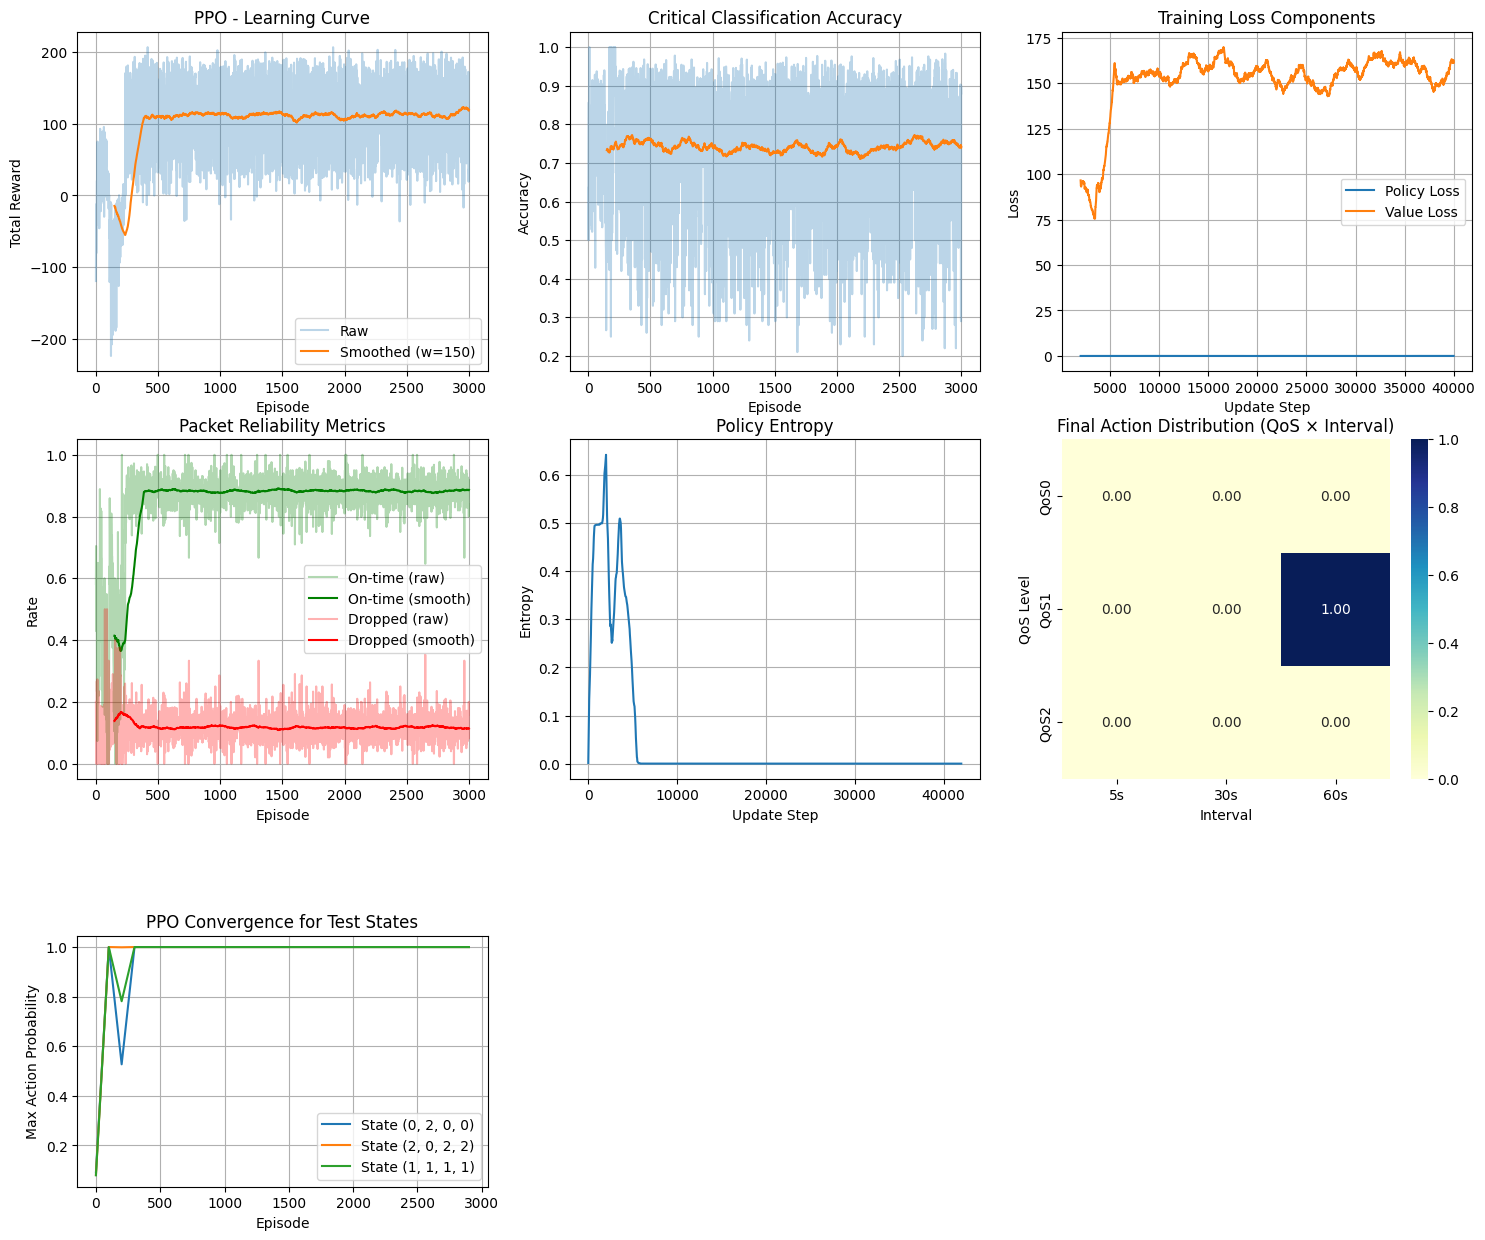


PPO Policy Analysis with Expected Ideal Actions:

State (Δ0, B=2, L=0, D=0):
  Best action: QoS=1, Interval=60s, Critical=1
  Ideal QoS: 0, Ideal Interval: 5s
  Critical match: ✗
  Top 1: QoS=1✗, τ=60s✗, c=1 (P=1.000)
  Top 2: QoS=2✗, τ=5s✓, c=1 (P=0.000)
  Top 3: QoS=0✓, τ=60s✗, c=0 (P=0.000)

State (Δ2, B=0, L=2, D=2):
  Best action: QoS=1, Interval=60s, Critical=1
  Ideal QoS: 2, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=1✗, τ=60s✗, c=1 (P=1.000)
  Top 2: QoS=2✓, τ=5s✓, c=1 (P=0.000)
  Top 3: QoS=0✗, τ=60s✗, c=0 (P=0.000)

State (Δ1, B=1, L=1, D=1):
  Best action: QoS=1, Interval=60s, Critical=1
  Ideal QoS: 1, Ideal Interval: 5s
  Critical match: ✓
  Top 1: QoS=1✓, τ=60s✗, c=1 (P=1.000)
  Top 2: QoS=0✗, τ=60s✗, c=0 (P=0.000)
  Top 3: QoS=2✗, τ=5s✓, c=1 (P=0.000)

=== Final Metrics ===
Metric                    |      Value
--------------------------------------
Average Reward            |     118.07
Accuracy                  |     74.54%
Avg KL Divergence         |     0

In [6]:
# PPO implementation (for editing and experimenting)
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque, namedtuple, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.distributions import Categorical


class RealisticEnvSimulator:
    def __init__(self):
        self.battery = 1.0
        self.window_size = 20
        self.delay_window = []
        self.loss_window = []
        self.delta_ema = None
        self.delta_alpha = 0.1
        self.delta_std = 1.0

    def update_ema(self, x):
        if self.delta_ema is None:
            self.delta_ema = x
        else:
            self.delta_ema = self.delta_alpha * x + \
                (1 - self.delta_alpha) * self.delta_ema
        return self.delta_ema

    def compute_delta(self, x):
        ema = self.update_ema(x)
        delta = abs(x - ema) / (self.delta_std + 1e-8)
        return delta

    def compute_loss_rate(self):
        if len(self.loss_window) < self.window_size:
            return 0.0
        return 1.0 - np.mean(self.loss_window[-self.window_size:])

    def compute_avg_delay(self):
        if len(self.delay_window) == 0:
            return 0
        return np.mean(self.delay_window[-self.window_size:])

    def discretize_state(self, delta, battery, loss, delay):
        """Convert continuous observations to discrete levels"""
        # Delta level
        if delta < 1:
            delta_lvl = 0   # Small
        elif delta < 3:
            delta_lvl = 1  # Medium
        else:
            delta_lvl = 2           # Large

        # Battery level
        if battery < 0.3:
            battery_lvl = 0   # Low
        elif battery < 0.7:
            battery_lvl = 1  # Medium
        else:
            battery_lvl = 2               # High

        # Loss level
        if loss < 0.1:
            loss_lvl = 0    # Low
        elif loss < 0.3:
            loss_lvl = 1  # Medium
        else:
            loss_lvl = 2             # High

        # Delay level
        if delay < 100:
            delay_lvl = 0    # Low
        elif delay < 500:
            delay_lvl = 1  # Medium
        else:
            delay_lvl = 2              # High

        return delta_lvl, battery_lvl, loss_lvl, delay_lvl

    def simulate_environment(self, state, action):
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state
        qos, interval, critical = action

        # --- Generate raw input values ---
        sensor_value = np.random.uniform(10, 30)  # fake temp
        delta = self.compute_delta(sensor_value)

        # --- Energy usage ---
        qos_energy = 0.05 * qos
        interval_energy = 2.0 / interval
        energy_cost = qos_energy + interval_energy
        self.battery = max(0.0, self.battery - energy_cost * 0.05)

        # --- Delay simulation ---
        base_delay = np.random.normal(100 + 50 * (2 - qos), 20)
        delay = np.clip(base_delay + 1000 / interval, 0, 800)
        self.delay_window.append(delay)

        # --- Packet loss simulation ---
        loss_chance = 0.1 * (2 - qos) + 0.01 * delay / \
            100  # more delay = more loss
        is_delivered = np.random.rand() > loss_chance
        self.loss_window.append(int(is_delivered))

        # --- Status & latency ---
        packet_status = 'dropped'
        if is_delivered:
            packet_status = 'on_time' if delay < 300 else 'late'
        latency = delay if is_delivered else 1000

        # --- Discretization for next state ---
        next_delta_lvl = 0 if delta < 1 else (1 if delta < 3 else 2)
        next_battery_lvl = 0 if self.battery < 0.3 else (
            1 if self.battery < 0.7 else 2)
        loss_rate = self.compute_loss_rate()
        next_loss_lvl = 0 if loss_rate < 0.1 else (1 if loss_rate < 0.3 else 2)
        avg_delay = self.compute_avg_delay()
        next_delay_lvl = 0 if avg_delay < 100 else (
            1 if avg_delay < 500 else 2)

        new_state = (next_delta_lvl, next_battery_lvl,
                     next_loss_lvl, next_delay_lvl)

        # --- True criticality logic ---
        total_risk = delta_lvl + (2 - battery_lvl) + loss_lvl + delay_lvl + qos
        normalized_risk = total_risk / 5
        true_crit = 1 if normalized_risk >= 1 else 0

        return new_state, packet_status, true_crit, energy_cost, latency


# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the experience tuple
Transition = namedtuple('Transition',
                        ('state', 'action', 'reward', 'next_state', 'done', 'log_prob', 'value'))


class PPOBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
        self.states = []
        self.actions = []
        self.rewards = []
        self.next_states = []
        self.dones = []
        self.log_probs = []
        self.values = []
        self.advantages = []
        self.returns = []

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def clear_episode_data(self):
        self.states = []
        self.actions = []
        self.rewards = []
        self.next_states = []
        self.dones = []
        self.log_probs = []
        self.values = []

    def store_episode_data(self, state, action, reward, next_state, done, log_prob, value):
        self.states.append(torch.tensor(state, dtype=torch.float32))
        self.actions.append(action)
        self.rewards.append(reward)
        self.next_states.append(next_state)
        self.dones.append(done)
        self.log_probs.append(log_prob)
        self.values.append(value)

    def compute_advantages(self, gamma=0.99, gae_lambda=0.95):
        # Convert to numpy arrays
        rewards = np.array(self.rewards)
        values = np.array(self.values)
        dones = np.array(self.dones)

        # Compute returns and advantages using GAE
        advantages = np.zeros_like(rewards)
        last_advantage = 0
        last_value = values[-1]

        for t in reversed(range(len(rewards))):
            if t + 1 < len(rewards):
                delta = rewards[t] + gamma * \
                    values[t+1] * (1 - dones[t]) - values[t]
            else:
                delta = rewards[t] + gamma * \
                    last_value * (1 - dones[t]) - values[t]
            advantages[t] = delta + gamma * \
                gae_lambda * (1 - dones[t]) * last_advantage
            last_advantage = advantages[t]

        # Compute returns
        self.returns = advantages + values

        # Normalize advantages
        self.advantages = (advantages - advantages.mean()) / \
            (advantages.std() + 1e-8)

        # Convert to tensors
        self.states = torch.FloatTensor(np.array(self.states)).to(device)
        self.actions = torch.LongTensor(np.array(self.actions)).to(device)
        self.log_probs = torch.FloatTensor(np.array(self.log_probs)).to(device)
        self.returns = torch.FloatTensor(self.returns).to(device)
        self.advantages = torch.FloatTensor(self.advantages).to(device)

        return len(self.states)


class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ActorCritic, self).__init__()

        # Shared feature extractor
        self.shared_layers = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU()
        )

        # Actor head
        self.actor = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

        # Critic head
        self.critic = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        shared_features = self.shared_layers(x)
        action_probs = torch.softmax(self.actor(shared_features), dim=-1)
        state_values = self.critic(shared_features)
        return action_probs, state_values


class PPOAgent:
    def __init__(self):
        self.env = RealisticEnvSimulator()

        # Action space definitions (same as DQN)
        self.qos_levels = [0, 1, 2]
        self.intervals = [5, 30, 60]  # in seconds
        self.critical_flags = [0, 1]
        self.state_action_visits = defaultdict(int)
        self.state_visits = defaultdict(int)
        # Environment parameters
        self.state_dims = [3, 3, 3, 3]  # Δ, Battery, Loss, Delay levels
        self.state_dim = len(self.state_dims)
        self.action_dims = [3, 3, 2]  # QoS, Interval, Critical
        self.num_actions = np.prod(self.action_dims)

        # PPO parameters
        self.gamma = 0.99
        self.gae_lambda = 0.95
        self.clip_param = 0.20
        self.ppo_epochs = 6
        self.num_minibatches = 2
        self.lr = 2e-3
        self.entropy_coef = 0.005
        self.value_loss_coef = 0.4
        self.max_grad_norm = 0.8

        # Networks
        self.policy = ActorCritic(self.state_dim, self.num_actions).to(device)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=self.lr)

        # Buffer
        self.buffer = PPOBuffer(50000)

        # Reward parameters (same as DQN)
        self.reward_weights = {
            'timeliness': 1.5,
            'criticality': 2.0,
            'qos_match': 2.0,
            'interval_match': 2.0,
            'tau_cost': 1.0,
            'qos_cost': 1.0,
            'kappa': 2.0,
            'latency_penalty': 0.5
        }

        # Metrics tracking
        self.metrics = {
            'episode_rewards': [],
            'classification_accuracy': [],
            'energy_consumption': [],
            'on_time_rate': [],
            'drop_rate': [],
            'avg_latency': [],
            'action_distribution': defaultdict(list),
            'convergence_data': [],
            'loss_values': [],
            'qos_distribution': [],
            'value_loss': [],
            'policy_loss': [],
            'entropy': [],
            'kl_divergence': [],  
            'clip_fraction': []
        }

    def action_to_index(self, qos, interval, critical):
        interval_idx = self.intervals.index(interval)
        return qos * 6 + interval_idx * 2 + critical

    def state_to_index(self, delta_lvl, battery_lvl, loss_lvl, delay_lvl):
        return (delta_lvl * 27 + battery_lvl * 9 + loss_lvl * 3 + delay_lvl)
    def index_to_action(self, action_idx):
        qos = action_idx // 6
        remainder = action_idx % 6
        interval_idx = remainder // 2
        critical = remainder % 2
        return qos, self.intervals[interval_idx], critical

    def _get_ideal_qos(self, state):
        """Dynamic ideal QoS considering multiple factors"""
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state

        # Higher QoS when network conditions are bad OR delta is large
        if loss_lvl >= 2 or delay_lvl >= 2 or delta_lvl >= 2:
            return 2
        elif (loss_lvl >= 1 or delay_lvl >= 1) and battery_lvl >= 1:
            return 1
        else:
            return 0

    def _get_ideal_interval(self, state):
        """Dynamic interval considering delta and battery"""
        delta_lvl, battery_lvl, _, _ = state

        # More frequent updates when delta is high OR battery is good
        if delta_lvl == 2 or battery_lvl >= 1:
            return 5
        elif delta_lvl == 1:
            return 30
        else:
            return 60

    def get_state_tensor(self, state):
        return torch.FloatTensor(state).unsqueeze(0).to(device)

    def select_action(self, state):
        state_tensor = self.get_state_tensor(state)
        with torch.no_grad():
            action_probs, state_value = self.policy(state_tensor)

        dist = Categorical(action_probs)
        action_idx = dist.sample()
        log_prob = dist.log_prob(action_idx)

        return action_idx.item(), log_prob.item(), state_value.item()

    def calculate_reward(self, state, action, packet_status, true_crit, latency):
        """Same reward function as DQN implementation"""
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state
        qos, interval, critical = action

        # 1. Timeliness Reward (R_rel)
        if packet_status == 'on_time':
            R_rel = 1.0
        elif packet_status == 'late':
            R_rel = 0.5
        else:  # dropped
            R_rel = -1.0

        # 2. Criticality Reward (R_crit)
        R_crit = 1.0 if critical == true_crit else -1.0

        # 3. QoS-Match Reward (R_qos)
        ideal_qos = 2 if (loss_lvl >= 2 or delay_lvl >= 2) else \
            1 if (loss_lvl >= 1 or delay_lvl >= 1) else 0
        R_qos = 1.0 if qos == ideal_qos else -1.0

        # 4. Interval-Match Reward (R_int)
        ideal_interval = 5 if delta_lvl == 2 else \
            30 if delta_lvl == 1 else 60
        R_int = 1.0 if interval == ideal_interval else -1.0

        # Energy Penalty Calculation
        battery = 0.3 + battery_lvl * 0.4
        f_Bt = 1 + self.reward_weights['kappa'] * (1 - battery)
        C_qos = qos / 2
        C_int = (60 - interval) / (60 - 5)
        penalty = f_Bt * (self.reward_weights['tau_cost'] * C_int +
                          self.reward_weights['qos_cost'] * C_qos)

        # Total reward with weighted components
        total_reward = (self.reward_weights['timeliness'] * R_rel +
                        self.reward_weights['criticality'] * R_crit +
                        self.reward_weights['qos_match'] * R_qos +
                        self.reward_weights['interval_match'] * R_int -
                        penalty)

        # Additional penalty for latency
        total_reward -= self.reward_weights['latency_penalty'] * \
            min(1, latency/800)

        return np.clip(total_reward, -5.0, 5.0)

    def update(self):
        # turn your stored list of values into a tensor once
        self.buffer.compute_advantages(self.gamma, self.gae_lambda)

        # Convenience tensors (detached copies for value‑clipping)
        values_tensor = torch.tensor(
            self.buffer.values, dtype=torch.float32, device=device)

        num_steps = len(self.buffer.states)
        batch_size = max(1, num_steps // self.num_minibatches)
        batch_indices = np.arange(num_steps)

        for _ in range(self.ppo_epochs):
            np.random.shuffle(batch_indices)

            for start in range(0, num_steps, batch_size):
                idx = batch_indices[start: start + batch_size]

                # --- build minibatch ----------------------------------------------------
                states = self.buffer.states[idx]
                actions = self.buffer.actions[idx]
                old_logp = self.buffer.log_probs[idx]
                returns = self.buffer.returns[idx]
                adv = self.buffer.advantages[idx]
                old_values = values_tensor[idx]

                # --- forward pass -------------------------------------------------------
                new_probs, new_values = self.policy(states)
                dist = Categorical(new_probs)

                logp_new = dist.log_prob(actions)
                entropy = dist.entropy().mean()

                # --- ratio / surrogate losses ------------------------------------------
                ratio = torch.exp(logp_new - old_logp)
                surr1 = ratio * adv
                surr2 = torch.clamp(
                    ratio, 1.0 - self.clip_param, 1.0 + self.clip_param) * adv
                policy_loss = -torch.min(surr1, surr2).mean()

                # --- value loss (clipped) ----------------------------------------------
                value_pred_clipped = old_values + torch.clamp(
                    new_values.squeeze() - old_values,
                    -self.clip_param,
                    +self.clip_param,
                )
                value_losses = (new_values.squeeze() - returns).pow(2)
                value_losses_clipped = (value_pred_clipped - returns).pow(2)
                value_loss = 0.5 * \
                    torch.max(value_losses, value_losses_clipped).mean()

                # --- compute diagnostics -----------------------------------------------
                with torch.no_grad():
                    # Approx KL divergence between old and new policy
                    # abs just in case
                    kl_div = (old_logp - logp_new).mean().abs()
                    # Fraction of samples where ratio was clipped
                    clip_fraction = ((ratio > 1.0 + self.clip_param)
                                     | (ratio < 1.0 - self.clip_param)).float().mean()

                # --- total loss & optimisation -----------------------------------------
                loss = policy_loss + self.value_loss_coef * \
                    value_loss - self.entropy_coef * entropy

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    self.policy.parameters(), self.max_grad_norm)
                self.optimizer.step()
        
                # --- logging ------------------------------------------------------------
                self.metrics['policy_loss'].append(policy_loss.item())
                self.metrics['value_loss'].append(value_loss.item())
                self.metrics['entropy'].append(entropy.item())
                self.metrics['kl_divergence'].append(kl_div.item())
                self.metrics['clip_fraction'].append(clip_fraction.item())
                self.metrics['loss_values'].append(loss.item())

    def train(self, num_episodes=3000, eval_interval=100):
        print(f"Starting PPO training for {num_episodes} episodes...")

        for episode in tqdm(range(num_episodes)):
            # Initialize episode metrics
            episode_metrics = {
                'reward': 0,
                'correct_class': 0,
                'energy': 0,
                'packets_sent': 0,
                'on_time': 0,
                'dropped': 0,
                'latency': 0,
                'steps': 0,
                'qos_counts': [0, 0, 0]
            }

            # Initialize environment and state
            self.env = RealisticEnvSimulator()
            delta = np.random.uniform(0, 4)
            battery = np.random.uniform(0.1, 1.0)
            loss = np.random.uniform(0, 0.5)
            delay = np.random.uniform(0, 600)
            self.env.battery = battery
            state = self.env.discretize_state(delta, battery, loss, delay)

            done = False
            while not done and episode_metrics['steps'] < 100:
                # Select action
                action_idx, log_prob, value = self.select_action(state)
                action = self.index_to_action(action_idx)
                state_idx = self.state_to_index(*state)
                self.state_action_visits[(state_idx, action_idx)] += 1
                self.state_visits[state_idx] += 1
                # Simulate environment
                new_state, packet_status, true_crit, energy_cost, latency = \
                    self.env.simulate_environment(state, action)

                # Calculate reward
                reward = self.calculate_reward(
                    state, action, packet_status, true_crit, latency)

                # Check termination
                done = self.env.battery <= 0.05 or episode_metrics['steps'] >= 99

                # Store transition
                self.buffer.store_episode_data(
                    state, action_idx, reward, new_state, done, log_prob, value)

                # Track metrics
                episode_metrics['reward'] += reward
                episode_metrics['correct_class'] += 1 if action[2] == true_crit else 0
                episode_metrics['energy'] += energy_cost
                episode_metrics['packets_sent'] += 1
                episode_metrics['qos_counts'][action[0]] += 1

                if packet_status == 'on_time':
                    episode_metrics['on_time'] += 1
                    episode_metrics['latency'] += latency
                elif packet_status == 'dropped':
                    episode_metrics['dropped'] += 1

                episode_metrics['steps'] += 1
                state = new_state

            # Update policy after each episode
            if len(self.buffer.states) > 0:
                self.update()
                self.buffer.clear_episode_data()

            # Store episode metrics
            self.metrics['episode_rewards'].append(episode_metrics['reward'])
            self.metrics['classification_accuracy'].append(
                episode_metrics['correct_class'] / episode_metrics['steps'] if episode_metrics['steps'] > 0 else 0)
            self.metrics['energy_consumption'].append(
                episode_metrics['energy'])
            self.metrics['on_time_rate'].append(
                episode_metrics['on_time'] / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else 0)
            self.metrics['drop_rate'].append(
                episode_metrics['dropped'] / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else 0)
            self.metrics['avg_latency'].append(
                episode_metrics['latency'] / episode_metrics['on_time'] if episode_metrics['on_time'] > 0 else 0)

            # Track QoS distribution
            qos_dist = np.array(
                episode_metrics['qos_counts']) / episode_metrics['packets_sent'] if episode_metrics['packets_sent'] > 0 else np.array([0, 0, 0])
            self.metrics['qos_distribution'].append(qos_dist)

            # Evaluate policy periodically
            if episode % eval_interval == 0:
                self._evaluate_policy(episode)

        print("Training completed!")
        return self.metrics

    def _evaluate_policy(self, episode):
        """Evaluate current policy on fixed test states"""
        test_states = [
            (0, 2, 0, 0),  # Optimal conditions
            (2, 0, 2, 2),  # Worst conditions
            (1, 1, 1, 1)   # Mixed conditions
        ]

        action_counts = np.zeros((3, 3))  # QoS × Interval
        crit_counts = np.zeros(2)  # Critical flags
        state_probs = {}  # To hold max action probs per state

        for state in test_states:
            state_tensor = self.get_state_tensor(state)
            with torch.no_grad():
                probs, _ = self.policy(state_tensor)
                probs = probs.squeeze().cpu().numpy()
            max_prob = np.max(probs)
            state_probs[state] = max_prob  # Save max probability for plotting

            action_idx = np.argmax(probs)
            qos, interval, critical = self.index_to_action(action_idx)

            interval_idx = self.intervals.index(interval)
            action_counts[qos, interval_idx] += 1
            crit_counts[critical] += 1

        # Store for plotting and analysis
        self.metrics['convergence_data'].append({
            'episode': episode,
            'action_dist': action_counts / len(test_states),
            'crit_dist': crit_counts / len(test_states),
            'state_probs': state_probs
        })


    def plot_metrics(self):
        """Generate all diagnostic plots"""
        plt.figure(figsize=(18, 15))
        window = max(1, len(self.metrics['episode_rewards']) // 20)

        # 1. Learning Curve - Average Reward
        plt.subplot(3, 3, 1)
        rewards = self.metrics['episode_rewards']
        if len(rewards) > 0:
            smooth_rewards = np.convolve(
                rewards, np.ones(window)/window, mode='valid')
            plt.plot(rewards, alpha=0.3, label='Raw')
            plt.plot(range(window-1, len(rewards)), smooth_rewards,
                     label=f'Smoothed (w={window})')
        plt.xlabel('Episode')
        plt.ylabel('Total Reward')
        plt.title('PPO - Learning Curve')
        plt.legend()
        plt.grid(True)

        # 2. Classification Accuracy
        plt.subplot(3, 3, 2)
        accuracy = self.metrics['classification_accuracy']
        if len(accuracy) > 0:
            smooth_acc = np.convolve(
                accuracy, np.ones(window)/window, mode='valid')
            plt.plot(accuracy, alpha=0.3)
            plt.plot(range(window-1, len(accuracy)), smooth_acc)
        plt.xlabel('Episode')
        plt.ylabel('Accuracy')
        plt.title('Critical Classification Accuracy')
        plt.grid(True)

        # 3. Training Loss Components
        plt.subplot(3, 3, 3)
        if len(self.metrics['policy_loss']) > 0:
            window_loss = max(1, len(self.metrics['policy_loss']) // 20)
            smooth_policy_loss = np.convolve(
                self.metrics['policy_loss'], np.ones(window_loss)/window_loss, mode='valid')
            smooth_value_loss = np.convolve(self.metrics['value_loss'], np.ones(
                window_loss)/window_loss, mode='valid')
            plt.plot(range(
                window_loss-1, len(self.metrics['policy_loss'])), smooth_policy_loss, label='Policy Loss')
            plt.plot(range(
                window_loss-1, len(self.metrics['value_loss'])), smooth_value_loss, label='Value Loss')
            plt.xlabel('Update Step')
            plt.ylabel('Loss')
            plt.title('Training Loss Components')
            plt.legend()
            plt.grid(True)

        # 4. Reliability Metrics
        plt.subplot(3, 3, 4)
        on_time = self.metrics['on_time_rate']
        dropped = self.metrics['drop_rate']
        if len(on_time) > 0 and len(dropped) > 0:
            smooth_ot = np.convolve(
                on_time, np.ones(window)/window, mode='valid')
            smooth_dr = np.convolve(
                dropped, np.ones(window)/window, mode='valid')
            plt.plot(on_time, alpha=0.3, color='green', label='On-time (raw)')
            plt.plot(range(window-1, len(on_time)), smooth_ot,
                     color='green', label='On-time (smooth)')
            plt.plot(dropped, alpha=0.3, color='red', label='Dropped (raw)')
            plt.plot(range(window-1, len(dropped)), smooth_dr,
                     color='red', label='Dropped (smooth)')
        plt.xlabel('Episode')
        plt.ylabel('Rate')
        plt.title('Packet Reliability Metrics')
        plt.legend()
        plt.grid(True)

        # 5. Entropy
        plt.subplot(3, 3, 5)
        if len(self.metrics['entropy']) > 0:
            window_ent = max(1, len(self.metrics['entropy']) // 20)
            plt.plot(np.convolve(
                self.metrics['entropy'], np.ones(window_ent)/window_ent))
        plt.xlabel('Update Step')
        plt.ylabel('Entropy')
        plt.title('Policy Entropy')
        plt.grid(True)

        # 6. Action Distribution Heatmap (final)
        plt.subplot(3, 3, 6)
        if self.metrics['convergence_data']:
            final_actions = self.metrics['convergence_data'][-1]['action_dist']
            sns.heatmap(final_actions, annot=True, fmt='.2f',
                        xticklabels=['5s', '30s', '60s'],
                        yticklabels=['QoS0', 'QoS1', 'QoS2'],
                        cmap='YlGnBu')
            plt.title('Final Action Distribution (QoS × Interval)')
            plt.xlabel('Interval')
            plt.ylabel('QoS Level')
        #7. Q-value/Probability Convergence for Test States
        plt.subplot(4, 3, 10)
        test_states = [
            (0, 2, 0, 0),
            (2, 0, 2, 2),
            (1, 1, 1, 1)
        ]
        for state in test_states:
            episodes = [data['episode'] for data in self.metrics['convergence_data']]
            probs = [data['state_probs'][state] for data in self.metrics['convergence_data']]
            plt.plot(episodes, probs, label=f'State {state}')
        plt.xlabel('Episode')
        plt.ylabel('Max Action Probability')
        plt.title('PPO Convergence for Test States')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    def calculate_final_metrics(self, window=100):
        """Calculate and print final metrics for comparison"""
        metrics = {}

        # 1. Average Reward (last 100 epochs)
        if len(self.metrics['episode_rewards']) >= window:
            metrics['avg_reward'] = np.mean(
                self.metrics['episode_rewards'][-window:])
        else:
            metrics['avg_reward'] = np.mean(
                self.metrics['episode_rewards']) if self.metrics['episode_rewards'] else 0

        # 2. Accuracy (last 100 epochs)
        if len(self.metrics['classification_accuracy']) >= window:
            metrics['accuracy'] = np.mean(
                self.metrics['classification_accuracy'][-window:])
        else:
            metrics['accuracy'] = np.mean(
                self.metrics['classification_accuracy']) if self.metrics['classification_accuracy'] else 0

        # 3. Average KL Divergence (entire training)
        metrics['avg_kl'] = np.mean(
            self.metrics['kl_divergence']) if self.metrics['kl_divergence'] else 0

        # 4. Average Clip Fraction (entire training)
        metrics['avg_clip_frac'] = np.mean(
            self.metrics['clip_fraction']) if self.metrics['clip_fraction'] else 0

        # 5. Final ε Clip (this is constant in PPO)
        # PPO's clip parameter doesn't decay
        metrics['final_eps_clip'] = self.clip_param

        # 6. Additional useful metrics
        if len(self.metrics['energy_consumption']) >= window:
            metrics['avg_energy'] = np.mean(
                self.metrics['energy_consumption'][-window:])
        else:
            metrics['avg_energy'] = np.mean(
                self.metrics['energy_consumption']) if self.metrics['energy_consumption'] else 0

        if len(self.metrics['on_time_rate']) >= window:
            metrics['avg_on_time'] = np.mean(
                self.metrics['on_time_rate'][-window:])
        else:
            metrics['avg_on_time'] = np.mean(
                self.metrics['on_time_rate']) if self.metrics['on_time_rate'] else 0

        if len(self.metrics['drop_rate']) >= window:
            metrics['avg_drop'] = np.mean(self.metrics['drop_rate'][-window:])
        else:
            metrics['avg_drop'] = np.mean(
                self.metrics['drop_rate']) if self.metrics['drop_rate'] else 0

        # Print the results in a formatted table
        print("\n=== Final Metrics ===")
        print(f"{'Metric':<25} | {'Value':>10}")
        print("-" * 38)
        print(f"{'Average Reward':<25} | {metrics['avg_reward']:>10.2f}")
        print(f"{'Accuracy':<25} | {metrics['accuracy']:>10.2%}")
        print(f"{'Avg KL Divergence':<25} | {metrics['avg_kl']:>10.4f}")
        print(f"{'Avg Clip Fraction':<25} | {metrics['avg_clip_frac']:>10.2%}")
        print(f"{'Final ε Clip':<25} | {metrics['final_eps_clip']:>10.2f}")
        print(f"{'Avg Energy':<25} | {metrics['avg_energy']:>10.2f}")
        print(f"{'Avg On-Time Rate':<25} | {metrics['avg_on_time']:>10.2%}")
        print(f"{'Avg Drop Rate':<25} | {metrics['avg_drop']:>10.2%}")

        return metrics

    def analyze_policy(self):
        """Analyze the learned policy with expected ideal actions"""
        print("\nPPO Policy Analysis with Expected Ideal Actions:")

        test_states = [
            (0, 2, 0, 0),  # Small Δ, High battery, Low loss/delay
            (2, 0, 2, 2),  # Large Δ, Low battery, High loss/delay
            (1, 1, 1, 1)   # Medium everything
        ]

        for state in test_states:
            action_idx, _, _ = self.select_action(state)
            qos, interval, critical = self.index_to_action(action_idx)

            # Calculate expected ideal actions
            ideal_qos = self._get_ideal_qos(state)
            ideal_interval = self._get_ideal_interval(state)
            true_crit = 1 if (sum(state) + qos) / 5 >= 1 else 0

            print(
                f"\nState (Δ{state[0]}, B={state[1]}, L={state[2]}, D={state[3]}):")
            print(
                f"  Best action: QoS={qos}, Interval={interval}s, Critical={critical}")
            print(
                f"  Ideal QoS: {ideal_qos}, Ideal Interval: {ideal_interval}s")
            print(f"  Critical match: {'✓' if critical == true_crit else '✗'}")

            # Get action probabilities
            with torch.no_grad():
                state_tensor = self.get_state_tensor(state)
                action_probs, _ = self.policy(state_tensor)
                action_probs = action_probs.squeeze().cpu().numpy()

            # Show top 3 actions
            top_actions = np.argsort(action_probs)[-3:][::-1]
            for i, act_idx in enumerate(top_actions):
                q, tau, c = self.index_to_action(act_idx)
                match_qos = "✓" if q == ideal_qos else "✗"
                match_int = "✓" if tau == ideal_interval else "✗"
                print(
                    f"  Top {i+1}: QoS={q}{match_qos}, τ={tau}s{match_int}, c={c} (P={action_probs[act_idx]:.3f})")

    def summarize_coverage(self, well_visited_threshold=10, print_least_n=5):
        total_pairs = self.num_actions * 81
        total_pairs_encountered = len(self.state_action_visits)
        well_visited_pairs = sum(
            v >= well_visited_threshold for v in self.state_action_visits.values())
        unique_states_visited = len(self.state_visits)
        coverage_percent = 100 * total_pairs_encountered / total_pairs
        state_coverage = 100 * unique_states_visited / 81
        visit_counts = list(self.state_action_visits.values())
        most_visited = max(visit_counts) if visit_counts else 0
        least_visited = min(visit_counts) if visit_counts else 0
        print("\nState-Action Pair Coverage Summary:")
        print(
            f"  State-action pairs encountered: {total_pairs_encountered} / {total_pairs} ({coverage_percent:.2f}%)")
        print(
            f"  Well-visited pairs (≥{well_visited_threshold} visits): {well_visited_pairs} / {total_pairs}")
        print(
            f"  Unique states visited: {unique_states_visited} / 81 ({state_coverage:.2f}%)")
        print(f"  Most visited state-action pair: {most_visited} times")
        print(f"  Least visited state-action pair: {least_visited} times")
        print(
            f"  Median visits per encountered pair: {np.median(visit_counts) if visit_counts else 0:.1f}")
        print(
            f"  Average visits per encountered pair: {np.mean(visit_counts) if visit_counts else 0:.1f}")
        if print_least_n > 0 and visit_counts:
            print(
                f"\n{print_least_n} Least-visited (state, action) pairs and counts:")
            sorted_visits = sorted(
                self.state_action_visits.items(), key=lambda x: x[1])
            for ((s_idx, a_idx), count) in sorted_visits[:print_least_n]:
                state = (s_idx // 27, (s_idx % 27) //
                         9, (s_idx % 9) // 3, s_idx % 3)
                qos = a_idx // 6
                interval = [5, 30, 60][(a_idx % 6) // 2]
                critical = a_idx % 2
                print(
                    f"  State: {state}, Action: (QoS={qos}, Interval={interval}, Crit={critical}) --> {count} visits")


# Main execution
if __name__ == "__main__":
    # Initialize and train the agent
    agent = PPOAgent()
    metrics = agent.train(num_episodes=3000)

    # Plot all metrics
    agent.plot_metrics()

    # Analyze the learned policy
    agent.analyze_policy()
    agent.calculate_final_metrics()
    agent.summarize_coverage(well_visited_threshold=10)